In [4]:
%load_ext autoreload
%autoreload 2

import os,sys
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
import util as yu
from util import *
import util_Nsgm as yu2

yu.setpath('analysis_Nsgm_lbd')

ens='b'
tfs=[8,10,12,14,16,18,20]

yunit_mul=yu.ens2amul_iso[ens]*yu.ens2aInv[ens]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
[c2ptM,tf2c3ptM,c2ptCorrDic_NJN]=yu.load_pkl_reg('data',pathlabel='processData')
tf2c3ptM={tf:np.real(tf2c3ptM[tf]) for tf in tf2c3ptM.keys()}

In [6]:
[pars_jk_meff1st,pars_jk_meff2st,pars_jk_meff3st]=yu.load_pkl_reg('pars_jk_meffnst',pathlabel='analysis_noNsgm')
print('mN, dE1, r1, dE2, r2')
print(yu.jackme_un2str(pars_jk_meff2st[:,0]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff2st[:,1]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff2st[:,2]))
print(yu.jackme_un2str(pars_jk_meff3st[:,0]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff3st[:,1]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff3st[:,2]),yu.jackme_un2str(pars_jk_meff3st[:,3]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk_meff3st[:,4]))

print()
mN=pars_jk_meff2st[:,0]; mpi=140/yu.ens2aInv[ens]
p1=2*np.pi/yu.ens2NL[ens]
EN1=np.sqrt(mN**2+p1**2); Epi1=np.sqrt(mpi**2+p1**2)
print('dE(N1pi1):',yu.jackme_un2str((EN1+Epi1-mN)*yu.ens2aInv[ens]))
print('dE(N1pi1pi0):',yu.jackme_un2str((EN1+Epi1+mpi-mN)*yu.ens2aInv[ens]),'dE(N0pi1pi1):',yu.jackme_un2str((2*Epi1+0.0001*(mN-np.mean(mN)))*yu.ens2aInv[ens]))

mN, dE1, r1, dE2, r2
947.8(3.1) 597(39) 0.836(20)
944.7(5.7) 502(87) 0.710(44) 1740(170) 1.18(10)

dE(N1pi1): 311.888(97)
dE(N1pi1pi0): 451.888(97) dE(N0pi1pi1): 562.11532(31)


In [7]:
lbd=343
dEa=np.arange(280,1000,50)

def dEa2r(dEa):
    return (lbd**2-dEa**2)/(lbd**2)

dEa2r(1000)

-7.499859752314086

In [8]:
# 2pt GEVP

dt=2
ts=np.arange(0,22-dt)
t0s=ts+dt

t=[yu.GEVP(c,t0s,tList=ts) for c in c2ptM]
evals=np.array([eval for eval,evec in t])
evecs=np.array([evec for eval,evec in t])
evecsInv=np.linalg.inv(evecs)
# print(evals.shape,evecs.shape)

fig,axs=yu.getFigAxs(3,2,sharex='col',sharey='row')
ax=axs[0,0]
n2xmin_plt=[1,1]; n2xmax_plt=[17,17]
n2xmin_select=[15,12]; n2xmax_select=[17,16]
xunit=yu.ens2a[ens]; yunit=yu.ens2aInv[ens]/1000
for i in range(2):
    xmin_plt=n2xmin_plt[i]; xmax_plt=n2xmax_plt[i]
    xmin_select=n2xmin_select[i]; xmax_select=n2xmax_select[i]
    t=evals[:,:,i]
    t=np.log(t)/dt
    mean,err=yu.jackme(t)
    plt_x=t0s[xmin_plt:xmax_plt]*xunit; plt_y=mean[xmin_plt:xmax_plt]*yunit; plt_yerr=err[xmin_plt:xmax_plt]*yunit
    ax.errorbar(plt_x,plt_y,plt_yerr,color=yu.colors8[i])
    plt_x=t0s[xmin_select:xmax_select]*xunit; plt_y=mean[xmin_select:xmax_select]*yunit; plt_yerr=err[xmin_select:xmax_select]*yunit
    ax.errorbar(plt_x,plt_y,plt_yerr,color=yu.colors8[i],mfc='white')
ax.set_xlim([0,1.7])

ax=axs[0,1]

n2EN_selected={}
for i in range(2):
    xmin_select=n2xmin_select[i]; xmax_select=n2xmax_select[i]
    color=yu.colors8[i]
    t=evals[:,:,i]
    t=np.log(t)/dt
    xmins=np.arange(1,xmax_select-1)
    fits=yu.doFits_const(t,xmins,[xmax_select],corrQ=False)
    for fit in fits:
        (xmin,xmax),pars_jk,chi2_jk,Ndof = fit
        mean,err=yu.jackme(pars_jk)
        plt_x=t0s[xmin]*xunit; plt_y=mean[0]*yunit; plt_yerr=err[0]*yunit
        ax.errorbar(plt_x,plt_y,plt_yerr,color=color,mfc='white' if xmin==xmin_select else None)
        
        if xmin==xmin_select:
            n2EN_selected[i]=pars_jk[:,0]
            ax.axhspan(plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y,plt_yerr))
            axs[0,0].axhspan(plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2)
print(yu.jackme_un2str(n2EN_selected[0]*yunit*1000),yu.jackme_un2str(n2EN_selected[1]*yunit*1000),yu.jackme_un2str((n2EN_selected[1]-n2EN_selected[0])*yunit*1000))
ax.legend()

xmin_plt=1; xmax_plt=16
ax=axs[1,0]; yunit=1; color='r'
xmin_select=7; xmax_select=12
ax.set_ylim([-0.02,0.05])
t=np.real(evecs[:,:,0,1])/np.real(evecs[:,:,0,0])
mean,err=yu.jackme(t)
xmin=1
plt_x=t0s[xmin_plt:xmax_plt]*xunit; plt_y=mean[xmin_plt:xmax_plt]*yunit; plt_yerr=err[xmin_plt:xmax_plt]*yunit
ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
plt_x=t0s[xmin_select:xmax_select]*xunit; plt_y=mean[xmin_select:xmax_select]*yunit; plt_yerr=err[xmin_select:xmax_select]*yunit
ax.errorbar(plt_x,plt_y,plt_yerr,color=color,mfc='white')

ax=axs[1,1]
xmins=np.arange(1,xmax_select-1)
fits=yu.doFits_const(t,xmins,[xmax_select],corrQ=False)
for fit in fits:
    (xmin,xmax),pars_jk,chi2_jk,Ndof = fit
    mean,err=yu.jackme(pars_jk)
    plt_x=t0s[xmin]*xunit; plt_y=mean[0]*yunit; plt_yerr=err[0]*yunit
    ax.errorbar(plt_x,plt_y,plt_yerr,color=color,mfc='white' if xmin==xmin_select else None)
    
    if xmin==xmin_select:
        v_selected=pars_jk[:,0]
        ax.axhspan(plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y,plt_yerr))
        axs[1,0].axhspan(plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2)
ax.legend()

ax=axs[2,0]; yunit=1
# ax.set_ylim([-0.01,0.01])
t=1/(np.real(evecs[:,:,0,0])*np.real(evecsInv[:,:,0,0]))-1
mean,err=yu.jackme(t)
xmin=1
plt_x=t0s[xmin_plt:xmax_plt]*xunit; plt_y=mean[xmin_plt:xmax_plt]*yunit; plt_yerr=err[xmin_plt:xmax_plt]*yunit
ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
plt_x=t0s[xmin_select:xmax_select]*xunit; plt_y=mean[xmin_select:xmax_select]*yunit; plt_yerr=err[xmin_select:xmax_select]*yunit
ax.errorbar(plt_x,plt_y,plt_yerr,color=color,mfc='white')

ax=axs[2,1]
xmins=np.arange(1,xmax_select-1)
fits=yu.doFits_const(t,xmins,[xmax_select],corrQ=False)
for fit in fits:
    (xmin,xmax),pars_jk,chi2_jk,Ndof = fit
    mean,err=yu.jackme(pars_jk)
    plt_x=t0s[xmin]*xunit; plt_y=mean[0]*yunit; plt_yerr=err[0]*yunit
    ax.errorbar(plt_x,plt_y,plt_yerr,color=color,mfc='white' if xmin==xmin_select else None)
    
    if xmin==xmin_select:
        w_selected=pars_jk[:,0]
        ax.axhspan(plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2,label=yu.un2str(plt_y,plt_yerr))
        axs[2,0].axhspan(plt_y-plt_yerr,plt_y+plt_yerr,color=color,alpha=0.2)
ax.legend()

axs[0,0].set_ylabel(r'$E_{eff}$')
axs[1,0].set_ylabel(r'$v_{01}/v_{00}$')
axs[2,0].set_ylabel(r'W')

yu.finalizePlot('GEVP')

956.9(2.1) 1281(38) 324(38)


In [9]:
# tf2ratio_GEVP_unmatched={}
# for tf in tfs:
#     t=[ (c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
#         (c2ptM[tf,0,0] + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1] )[None]    \
#         for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)]
#     tf2ratio_GEVP_unmatched[tf]=np.array(t)

# tf2ratio_GEVP_matched={}
# for tf in tfs:
#     t=[ (c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
#         (c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1] )[None]    \
#         for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)]
#     tf2ratio_GEVP_matched[tf]=np.array(t)

# dic={'tf2ratio':tf2ratio_GEVP_matched, 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
# fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
# dic={'tf2ratio':tf2ratio_GEVP_unmatched, 'mfc:[global]':['White'], 'shift:[rainbow,midpoint,fit]':[0.2,0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
# fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
# fig.suptitle('match vs unmatch')
# yu.finalizePlot('Rd_match_vs_unmatch')

In [10]:
# tf2ratio_GEVP_w={}
# for tf in tfs:
#     t=[ (c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
#         (c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1] )[None]    \
#         for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)]
#     tf2ratio_GEVP_w[tf]=np.array(t)
    
# tf2ratio_GEVP_0w={}
# for tf in tfs:
#     t=[ (c3ptM[:,0,0]*(1) + v*(1)*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
#         (c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1] )[None]    \
#         for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)]
#     tf2ratio_GEVP_0w[tf]=np.array(t)
    
# tf2ratio_GEVP_0w_0v2={}
# for tf in tfs:
#     t=[ (c3ptM[:,0,0]*(1) + v*(1)*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
#         (c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) )[None]    \
#         for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)]
#     tf2ratio_GEVP_0w_0v2[tf]=np.array(t)
    
# dic={'tf2ratio':tf2ratio_GEVP_w, 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
# fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
# dic={'tf2ratio':tf2ratio_GEVP_0w, 'mfc:[global]':['White'], 'shift:[rainbow,midpoint,fit]':[-0.2,-0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
# fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
# dic={'tf2ratio':tf2ratio_GEVP_0w_0v2, 'mfc:[global]':['White'], 'shift:[rainbow,midpoint,fit]':[0.2,0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
# fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
# fig.suptitle('0w vs w vs w_0v2')
# yu.finalizePlot('Rd_compare_w_v2')

In [11]:
tf2ratio_noGEVP={tf:tf2c3ptM[tf][:,:,0,0]/c2ptCorrDic_NJN[tf][:,None] for tf in tfs}
tf2ratio_GEVP={}
for tf in tfs:
    t=[ (c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
        (c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1] )[None]    \
        for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)]
    tf2ratio_GEVP[tf]=np.array(t)

In [12]:
dic={'tf2ratio':tf2ratio_noGEVP, 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[0.2,0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
yu.finalizePlot('R_only')

dic={'tf2ratio':tf2ratio_noGEVP, 'mfc:[global]':['white'], 'shift:[rainbow,midpoint,fit]':[0.2,0.2,0], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
axs[0,0].set_ylim([0,80])
dic={'tf2ratio':tf2ratio_GEVP, 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'],figAxs=(fig,axs))
yu.finalizePlot('Rd')

dic={'tf2ratio':tf2ratio_GEVP, 'mfc:[global]':['None'], 'xyunit':(yu.ens2a[ens],yunit_mul) }
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint'])
yu.finalizePlot('Rd_only')

In [13]:
fig,axs=yu.getFigAxs(1,1)
ax=axs[0,0]
xunit,yunit=(yu.ens2a[ens],yunit_mul)

for itf,tf in enumerate(tfs):
    color=yu.colors8[itf]
    t=tf2ratio_GEVP[tf]-tf2ratio_GEVP[tf][:,tf//2][:,None]
    mean,err=yu.jackme(t)
    print(tf,yu.jackme_un2str(t))
    tcs=np.arange(1,tf)
    plt_x=(tcs-tf/2)*xunit; plt_y=mean[tcs]*yunit+tf; plt_yerr=err[tcs]*yunit
    ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
    
    tcmin=5
    tcs=np.arange(tcmin,tf-tcmin+1)
    plt_x=(tcs-tf/2)*xunit; plt_y=mean[tcs]*yunit+tf; plt_yerr=err[tcs]*yunit
    ax.errorbar(plt_x,plt_y,plt_yerr,color=color,mfc='white')

yu.finalizePlot('Rd-mid+tf')

8 [0.39(44), 1.34(26), 0.67(12), 0.156(37), 0.0(0.0), 0.156(37), 0.67(12), 1.34(26), 0.39(44)]
10 [0.99(57), 1.78(37), 1.01(21), 0.408(96), 0.104(30), 0.0(0.0), 0.104(30), 0.408(96), 1.01(21), 1.78(37), 0.99(57)]
12 [0.63(66), 1.55(46), 0.95(29), 0.43(17), 0.153(82), 0.022(27), 0.0(0.0), 0.022(27), 0.153(82), 0.43(17), 0.95(29), 1.55(46), 0.63(66)]
14 [0.11(69), 1.29(50), 0.77(35), 0.33(23), 0.12(14), 0.007(75), -0.016(28), 0.0(0.0), -0.016(28), 0.007(75), 0.12(14), 0.33(23), 0.77(35), 1.29(50), 0.11(69)]
16 [0.12(78), 1.16(58), 0.60(42), 0.19(30), 0.00(21), -0.05(14), -0.030(82), 0.003(33), 0.0(0.0), 0.003(33), -0.030(82), -0.05(14), 0.00(21), 0.19(30), 0.60(42), 1.16(58), 0.12(78)]
18 [-0.56(83), 0.89(65), 0.44(51), 0.09(39), -0.06(31), -0.05(23), -0.03(16), -0.016(92), -0.026(35), 0.0(0.0), -0.026(35), -0.016(92), -0.03(16), -0.05(23), -0.06(31), 0.09(39), 0.44(51), 0.89(65), -0.56(83)]
20 [-1.97(99), -0.33(80), -0.79(67), -0.99(57), -0.97(48), -0.76(41), -0.64(32), -0.45(24), -0.23

In [14]:
lower=-0.1; upper=0.2
def transform(z):
    return lower + (upper - lower) / (1.0 + np.exp(-z))
def inverse_transform(p):
    if not lower < p < upper:
        raise ValueError("p must be strictly between lower and upper.")
    return np.log((p - lower) / (upper - p))

def v2tf2ratio(v):
    v=transform(v)
    return {tf: np.array([(c3ptM[:,0,0] + v*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
        (c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) )[None]    \
        for c3ptM,c2ptM,c2pt in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf])]) \
        for tf in tfs}
def vjk2tf2ratio(vjk):
    vjk=np.array([transform(v) for v in vjk])
    return {tf: np.array([(c3ptM[:,0,0] + v*(c3ptM[:,0,1]+c3ptM[:,1,0]) ) /  \
        (c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) )[None]    \
        for c3ptM,c2ptM,c2pt,v in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],vjk)]) \
        for tf in tfs}

corrQ=False
fits=yu.getFits(label=f'lbd_{corrQ}')

dic={
    'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio_noGEVP,None,None,None,None],
    'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
    'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,None,None],
    'xyunit':[yu.ens2a[ens],yunit_mul],
    'mfc:[global]':['White'],
}
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint','fit_const'],colHeaders=None)
(tfmin,tcmin)=(8,4)
fit_MA=yu.doMA_3pt(fits,fitlabels=[(tfmin,tcmin)])
pars_jk,probs_jk,_=fit_MA
print(yu.jackme_un2str(pars_jk))
dic={
    'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[vjk2tf2ratio(pars_jk[:,1]),None,fits,None,None],
    'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,fit_MA,None,None],
    'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,None,None],
    'xyunit':[yu.ens2a[ens],yunit_mul],
    # 'mfc:[global]':['None'],
}
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint','fit_const'],colHeaders=None,figAxs=(fig,axs))
ax=axs[0,0]; ax.set_ylim([0,80])
yu.finalizePlot('lbdfit')

[27.0(1.2), -0.455(20)]


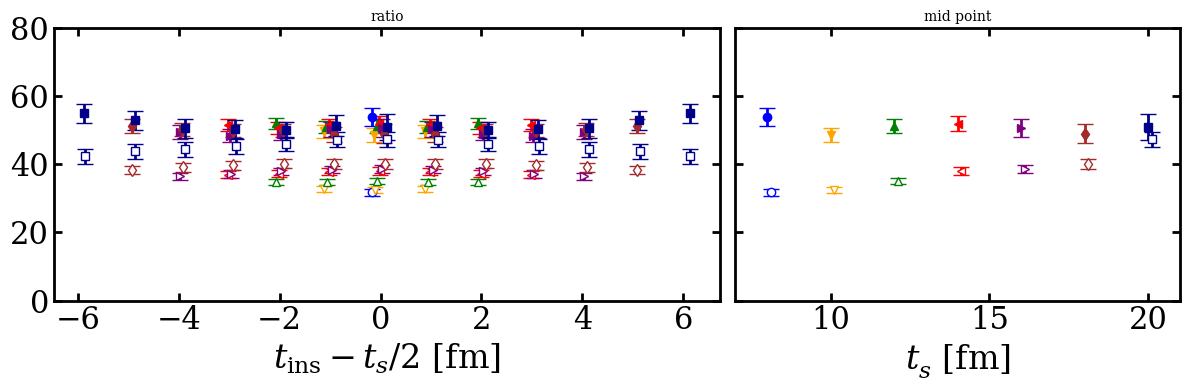

In [15]:
n=3
def dE2tf2ratio(dE):
    lbd0=dE*n
    lbd=np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
    
    tf2ratio={}
    for tf in tfs:
        c2=np.array([c2ptM[tf,0,0]   for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        c3=np.array([c3ptM[:,0,0] for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        
        c3pt=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
        c2pt=(lbd**2)*c2
        
        ratio=c3pt/c2pt[:,None]
        tf2ratio[tf]=ratio
    return tf2ratio

def dE2tf2ratio_GEVP(dE):
    lbd0=dE*n
    lbd=np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
    
    tf2ratio={}
    for tf in tfs:
        c2=np.array([c2pt + v*(c2ptM[tf,0,1]+c2ptM[tf,1,0]) + v**2*c2ptM[tf,1,1]  for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        c3=np.array([c3ptM[:,0,0]*(1-w**2) + v*(1+w)*(c3ptM[:,0,1]+c3ptM[:,1,0])  for c3ptM,c2ptM,c2pt,v,w in zip(tf2c3ptM[tf],c2ptM,c2ptCorrDic_NJN[tf],v_selected,w_selected)])
        
        c3pt=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
        c2pt=(lbd**2)*c2
        
        ratio=c3pt/c2pt[:,None]
        tf2ratio[tf]=ratio
    return tf2ratio

fig,axs=yu.makePlot_3pt_rainbow_compare(dE2tf2ratio(343/yu.ens2aInv[ens]),dE2tf2ratio_GEVP((800)/yu.ens2aInv[ens]),shift2=0.1,mid_tfshift2=0.1,tcmin=n+1,tcmin2=n+1,yunit=yunit_mul)
axs[0,0].set_ylim([0,80])
yu.finalizePlot()

[verbose1] tfmin=8;
[verbose1] tfmin=10;
[verbose1] tfmin=12;
[verbose1] tfmin=14;
[verbose1] tfmin=16;
50.9(4.2) 720(180) -31.8(7.5)


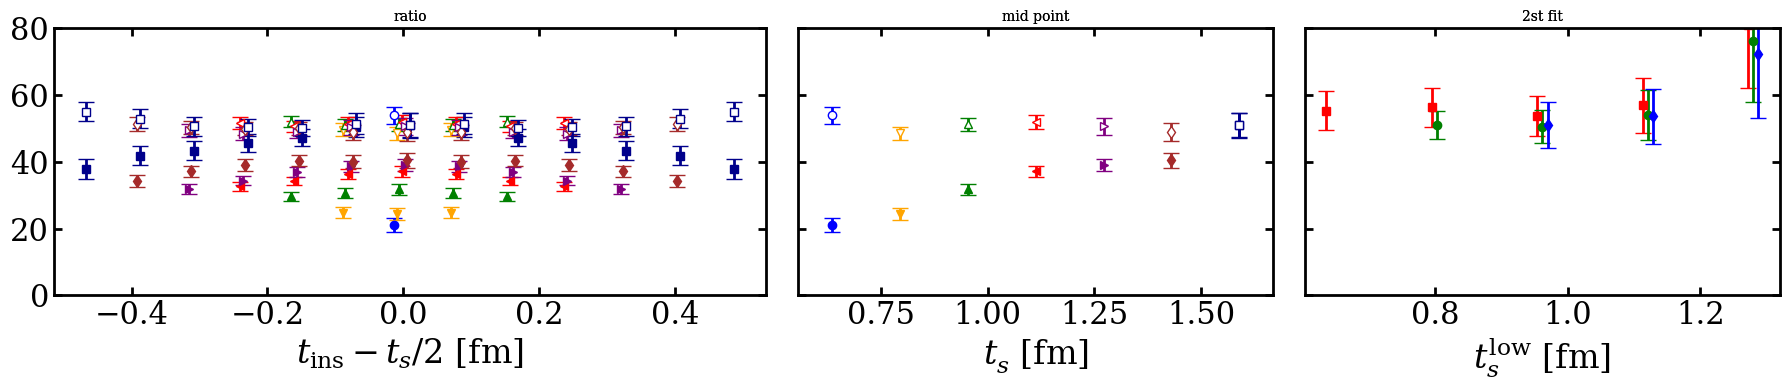

In [16]:
tf2ratio=dE2tf2ratio_GEVP((343+100)/yu.ens2aInv[ens])

tfmins=[8,10,12,14,16]
tcmins=[4,5,6]
fits=yu.doFits_3pt('2st2step_SYM_0ra11',tf2ratio,tfmins,tcmins,pars_jk_meff2st=pars_jk_meff2st,symmetrizeQ=True,label=f'dE2tf2ratio_GEVP_343_2st',verbose=1,overwrite=True)

fitlabel,pars_jk,chi2_jk,Ndof=[fit for fit in fits if fit[0]==(10,5)][0]
print(yu.jackme_un2str(pars_jk[:,0]*yunit_mul),yu.jackme_un2str(pars_jk[:,1]*yu.ens2aInv[ens]),yu.jackme_un2str(pars_jk[:,2]))

dic={
    'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[tf2ratio,None,None,None,fits],
    'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
    'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,n+1,None],
    'xyunit':[yu.ens2a[ens],yunit_mul],
    # 'fit_2st_rainbow_midpoint:[fittype,pars_jk_meff2st]':['2st2step_SYMshare',pars_jk_meff2st],
    # 'mfc:[global]':['None'],
}
fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint','fit_2st'])

dic={
    'base:[tf2ratio,fits_band,fits_const,fits_sum,fits_2st]':[dE2tf2ratio(343/yu.ens2aInv[ens]),None,None,None,None],
    'WAMA:[fit_band_WA,fit_const_MA,fit_sum_MA,fit_2st_MA]':[None,None,None,None],
    'rainbow:[tfmin,tfmax,tcmin,dt]':[None,None,n+1,None],
    'xyunit':[yu.ens2a[ens],yunit_mul],
    'mfc:[global]':['white'],
}

fig,axs=yu.makePlot_3pt(dic,shows=['rainbow','midpoint','fit_2st'],figAxs=(fig,axs))

axs[0,0].set_ylim([0,80])
yu.finalizePlot()


In [17]:
# fig,axs=yu.getFigAxs(1,1)
# ax=axs[0,0]
# xunit,yunit=(yu.ens2a[ens],yunit_mul)

# tf2ratio=dE2tf2ratio_GEVP(343/yu.ens2aInv[ens])
# for itf,tf in enumerate(tfs):
#     color=yu.colors16[itf]
#     t=tf2ratio[tf]-tf2ratio[tf][:,tf//2][:,None]
#     mean,err=yu.jackme(t)
#     tcs=np.arange(n+1,tf-n)
#     plt_x=(tcs-tf/2)*xunit; plt_y=mean[tcs]*yunit+tf*2; plt_yerr=err[tcs]*yunit
#     ax.errorbar(plt_x,plt_y,plt_yerr,color=color)
    
# yu.finalizePlot()

In [18]:
# def lbd2tf2ratio(lbd):
#     n=2
#     lbd0=np.mean(pars_jk_meff2st[:,1])*n*0.6*lbd
#     lbd=np.sqrt(np.exp(-lbd0)+np.exp(lbd0)-2)
#     tf2ratio={}
#     for tf in tfs:
#         c3=tf2c3pt[tf]
#         c3=-(np.roll(c3,-n,axis=-1)+np.roll(c3,n,axis=-1)-2*c3) + lbd**2*c3
#         c2=(lbd**2)*c2pt[:,tf]j
#         tf2ratio[tf]=c3/c2[:,None]
    
#     tfmin={'const':10,'sum':10,'2st':10}[fittype]
#     tcmin={'const':4,'sum':1+n,'2st':1+n+1}[fittype]
#     if fittype=='2st':
#         fittype='2st2step_SYMshare'
#     fits=yu.doFits_3pt(fittype,tf2ratio,[tfmin],[tcmin],symmetrizeQ=True,pars_jk_meff2st=pars_jk_meff2st,corrQ=corrQ)
#     [(tfmin,tcmin),pars_jk,chi2_jk,Ndof]=fits[0]
#     return pars_jk[:,:1],chi2_jk,Ndof